In [1]:
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#### Apartado 1

In [2]:
def funcion_f(x):
    return (1.5 + np.cos(x))
def funcion_g(x):
    return (1.5 + np.cos(x**2))

def Area(f, a, b, t, theta, n=101):
    x = np.linspace(a, b, n)
    y = t + np.tan(theta) * x
    diferencia = np.maximum(0, f(x) - y)
    area = simpson(diferencia, x)
    return area


def proporcionArea(f, a, b, t, theta, n=101):
    x = np.linspace(a, b, n)
    A = simpson(f(x), x)
    area_superior = Area(f, a, b, t, theta, n)
    return area_superior / A         

#### Apartado 2

In [3]:

def angulo(t,f,a,b,n,error1=0.000001):
    theta_min = -np.pi / 2
    theta_max = np.pi / 2
    while abs(theta_max - theta_min) > error1:
        theta_mid = (theta_min + theta_max)/2

        proporcion_min = proporcionArea(f, a, b, t, theta_min)
        proporcion_max = proporcionArea(f, a, b, t, theta_mid)

        
        if (proporcion_min - 0.5) * (proporcion_max - 0.5) < 0:
            theta_max = theta_mid
        else:
            theta_min = theta_mid
    
    return (theta_min + theta_max) / 2

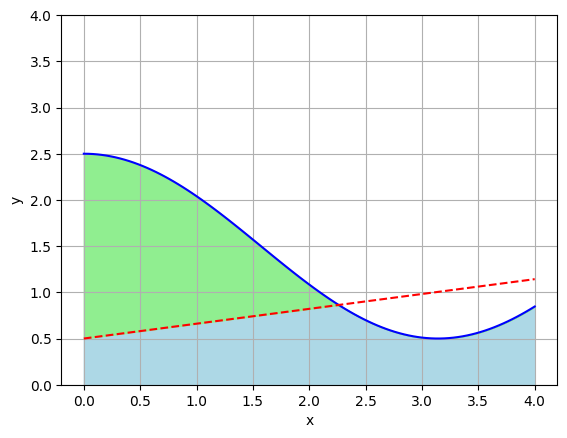

In [4]:
a = 0
b = 4
t = 0.5
n = 101

theta = angulo(t, funcion_f, a, b, n)
x = np.linspace(a, b, n)
y_func = funcion_f(x)
y_recta = t + np.tan(theta) * x

plt.plot(x, y_func, color="blue")
plt.plot(x, y_recta, color="red", linestyle="--")
plt.fill_between(x, 0, np.minimum(y_func, y_recta), color="lightblue")
plt.fill_between(x, np.minimum(y_func, y_recta), y_func, color="lightgreen")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(0, 4)
plt.grid()
plt.show()

#### Apartado 3

In [5]:
def rectaDivisionNewton(x0, funcion_f, funcion_g, a, b, c, d, n, error1=0.000001, error2= 0.000001):
    def f_angulo(t):
        return (angulo(t, funcion_f, a, b, n, error1) - angulo(t, funcion_g, c, d, n, error1))
    def derivada_f_angulo(t):
        return ((f_angulo(t + h) - f_angulo(t)) / h)
    
    h = 10**-3
    t = x0
    t1 = t - (f_angulo(t) / derivada_f_angulo(t))
    while abs(t1 - t) > error2:
        t = t1
        t1 = t - (f_angulo(t) / derivada_f_angulo(t))
    t = t1
    return t

In [6]:
rectaDivisionNewton(1, funcion_f, funcion_g, 0, 1, 1, 4, 101)

1.2755778839001373

### Apartdado 4

In [7]:
def rectaDivisoraBiseccion(f, g, a, b, c, d, n=101, error1=0.000001, error2=0.000001):
    def f_angulo(t):
        return (angulo(t, f, a, b, n, error1) - angulo(t, g, c, d, n, error1))
    min_t = 0
    max_t = 10
    
    while abs(max_t - min_t) > error1:
        mid_t = (min_t + max_t)/2

        angulo_min = f_angulo(min_t)
        angulo_max = f_angulo(mid_t)

        if angulo_min * angulo_max < 0:
            max_t = mid_t
        else:
            min_t = mid_t

    return (min_t + max_t) / 2



"""Este método puede dar error si el intervalo escogido es positivo y no cambia de signo, es decir que no tiene raiz.
También puede dar error si la funcion no es continua."""

'Este método puede dar error si el intervalo escogido es positivo y no cambia de signo, es decir que no tiene raiz.\nTambién puede dar error si la funcion no es continua.'

In [14]:
rectaDivisoraBiseccion(funcion_f, funcion_g, 0, 1, 1, 4, 101)

1.2755778431892395

### Apartado 5

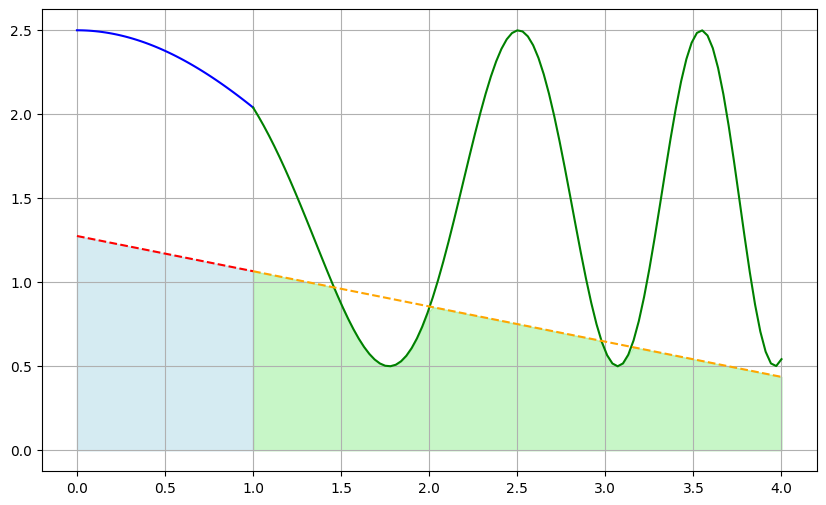

In [8]:
a, b, c, d = 0, 1, 1, 4
n = 101
x0 = 0.5


t = rectaDivisionNewton(1, funcion_f, funcion_g, a, b, c, d, n)
theta = angulo(t, funcion_f, a, b, n)


x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)
y_f = funcion_f(x_f)
y_g = funcion_g(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))


plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")


plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)
plt.grid()
plt.show()

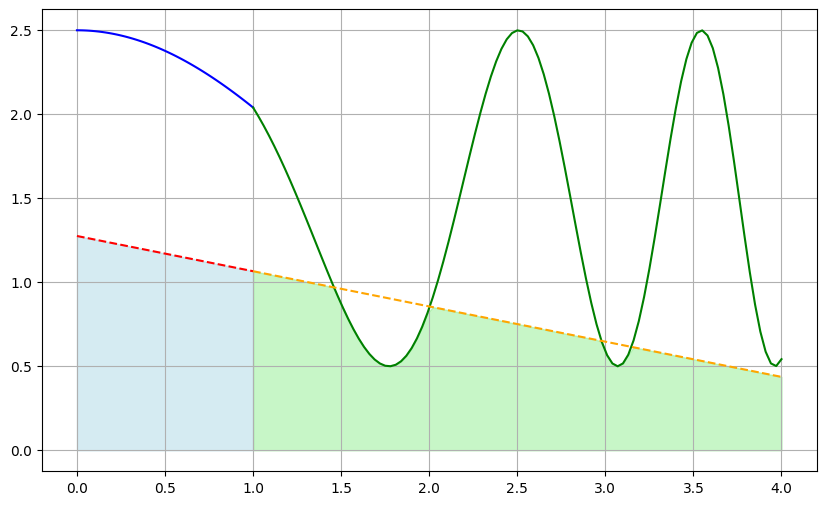

In [9]:
a, b, c, d = 0, 1, 1, 4
n = 101
x0 = 0.5


t = rectaDivisoraBiseccion(funcion_f, funcion_g, a, b, c, d, n)
theta = angulo(t, funcion_f, a, b, n)


x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)
y_f = funcion_f(x_f)
y_g = funcion_g(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))


plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")


plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)
plt.grid()
plt.show()

Ejemplos extra

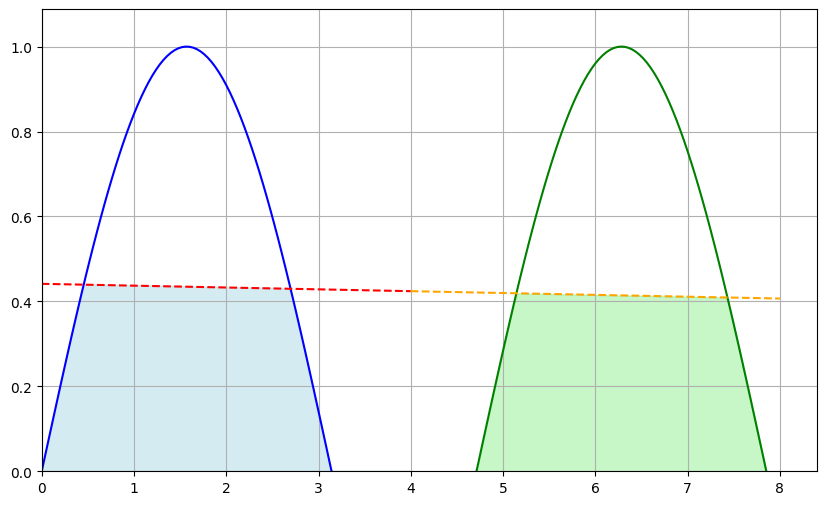

In [10]:
def f_x(x):
    return np.sin(x)

def g_x(x):
    return np.cos(x)

a, b, c, d = 0, 4, 4, 8 
n = 101
x0 = 0.5

t = rectaDivisionNewton(x0, f_x, g_x, a, b, c, d, n)

theta = angulo(t, f_x, a, b, n)

x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)

y_f = f_x(x_f)
y_g = g_x(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))

plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")

plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)

plt.xlim(0)
plt.ylim(0)

plt.grid(True)
plt.show()

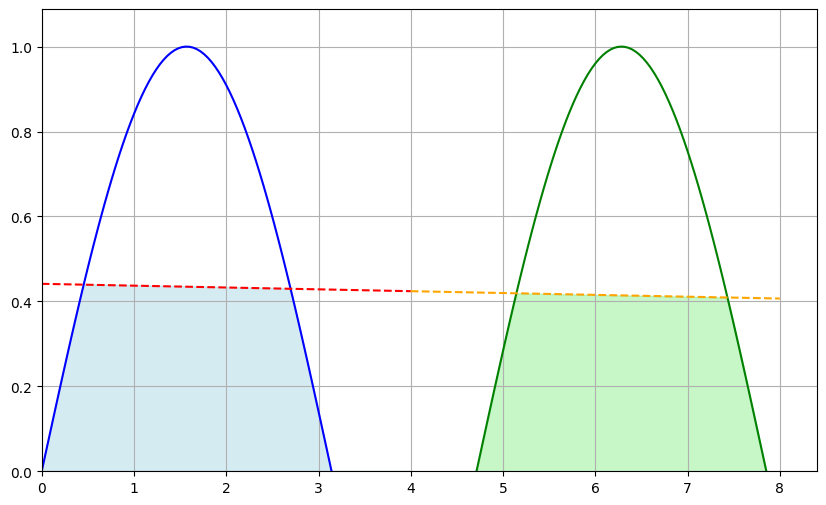

In [11]:
def f_x(x):
    return np.sin(x)

def g_x(x):
    return np.cos(x)

a, b, c, d = 0, 4, 4, 8 
n = 101
x0 = 0.5

t = rectaDivisoraBiseccion(f_x, g_x, a, b, c, d, n)

theta = angulo(t, f_x, a, b, n)

x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)

y_f = f_x(x_f)
y_g = g_x(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))

plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")

plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)

plt.xlim(0)
plt.ylim(0)

plt.grid(True)
plt.show()

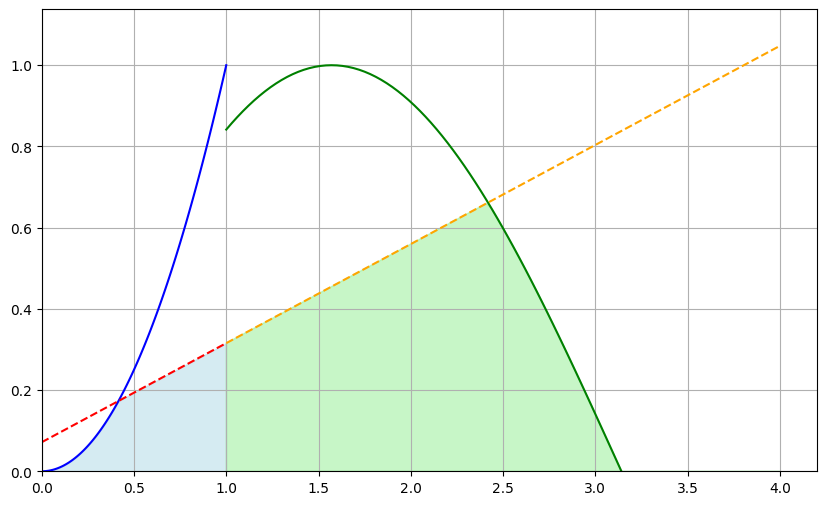

In [12]:
def f_x(x):
    return x**2

def g_x(x):
    return np.sin(x)

a, b, c, d = 0, 1, 1, 4
n = 101
x0 = 0.5

t = rectaDivisionNewton(x0, f_x, g_x, a, b, c, d, n)

theta = angulo(t, f_x, a, b, n)

x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)

y_f = f_x(x_f)
y_g = g_x(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))

plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")

plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)

plt.xlim(0)
plt.ylim(0)

plt.grid(True)
plt.show()

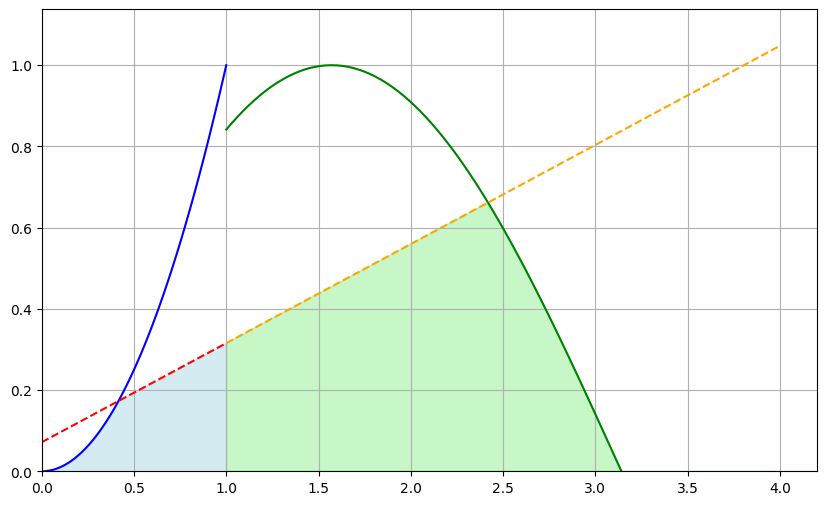

In [13]:
def f_x(x):
    return x**2

def g_x(x):
    return np.sin(x)

a, b, c, d = 0, 1, 1, 4
n = 101
x0 = 0.5

t = rectaDivisoraBiseccion(f_x, g_x, a, b, c, d, n)

theta = angulo(t, f_x, a, b, n)

x_f = np.linspace(a, b, n)
x_g = np.linspace(c, d, n)

y_f = f_x(x_f)
y_g = g_x(x_g)

y_recta_f = t + np.tan(theta) * x_f
y_recta_g = t + np.tan(theta) * x_g

plt.figure(figsize=(10, 6))

plt.plot(x_f, y_f, color="blue")
plt.plot(x_g, y_g, color="green")
plt.plot(x_f, y_recta_f, color="red", linestyle="--")
plt.plot(x_g, y_recta_g, color="orange", linestyle="--")

plt.fill_between(x_f, 0, np.minimum(y_f, y_recta_f), color="lightblue", alpha=0.5)
plt.fill_between(x_g, 0, np.minimum(y_g, y_recta_g), color="lightgreen", alpha=0.5)

plt.xlim(0)
plt.ylim(0)

plt.grid(True)
plt.show()